# Deep Learning Tutorial

--- 

## Part 1: from arrays to Tensors


## Part 2: Model's Architecture



## Part 3: Dataset & DataLoaders


## Part 4: The Training Loop

We will cover a practical Deep Learning Experiment by training a Convolutional Neural Network to perform a Downscaling Experiment. 





---

# Part 1: from Arrays to Tensors

Tensors are a specialized data structure that are very similar to arrays and matrices.
In PyTorch, we use tensors to encode the inputs and outputs of a model, as well as the model’s parameters.

Tensors are similar to [NumPy’s](https://numpy.org/) ndarrays, except that tensors can run on GPUs or other hardware accelerators. In fact, tensors and
NumPy arrays can often share the same underlying memory, eliminating the need to copy data. Tensors
are also optimized for automatic differentiation (see more about that later in the Autograd section). If you’re familiar with ndarrays, you’ll be right at home with the Tensor API. If not, follow along!

In [1]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

## 1.1 Initializing a Tensor

Tensors can be initialized in various ways. Take a look at the following examples:

**1. Directly from data**

Tensors can be created directly from data. The data type is automatically inferred.



In [3]:
data = [[1, 2],[3, 4]]
x_data = torch.tensor(data)

**2. From a NumPy array**

Tensors can be created from NumPy arrays (and vice versa).



In [4]:
np_data = np.array(data)
x_np = torch.from_numpy(np_data)

**3. From another tensor:**

The new tensor retains the properties (shape, datatype) of the argument tensor, unless explicitly overridden.



In [5]:
x_ones = torch.ones_like(x_data) # retains the properties of x_data
print(f"Ones Tensor: \n {x_ones} \n")

x_rand = torch.rand_like(x_data, dtype=torch.float) # overrides the datatype of x_data
print(f"Random Tensor: \n {x_rand} \n")

Ones Tensor: 
 tensor([[1, 1],
        [1, 1]]) 

Random Tensor: 
 tensor([[0.2271, 0.8857],
        [0.6297, 0.5980]]) 



**With random or constant values:**

``shape`` is a tuple of tensor dimensions. In the functions below, it determines the dimensionality of the output tensor.



In [6]:
shape = (2,3,)
rand_tensor = torch.rand(shape)
ones_tensor = torch.ones(shape)
zeros_tensor = torch.zeros(shape)

print(f"Random Tensor: \n {rand_tensor} \n")
print(f"Ones Tensor: \n {ones_tensor} \n")
print(f"Zeros Tensor: \n {zeros_tensor}")

Random Tensor: 
 tensor([[0.2483, 0.9304, 0.5567],
        [0.8355, 0.2731, 0.6302]]) 

Ones Tensor: 
 tensor([[1., 1., 1.],
        [1., 1., 1.]]) 

Zeros Tensor: 
 tensor([[0., 0., 0.],
        [0., 0., 0.]])


## 1.2 Attributes of a Tensor

Tensor attributes describe their shape, datatype, and the device on which they are stored.



In [7]:
tensor = torch.rand(3,4)

print(f"Shape of tensor: {tensor.shape}")
print(f"Datatype of tensor: {tensor.dtype}")
print(f"Device tensor is stored on: {tensor.device}")

Shape of tensor: torch.Size([3, 4])
Datatype of tensor: torch.float32
Device tensor is stored on: cpu


## 1.3 Operations on Tensors (to be discarded)

Over 100 tensor operations, including arithmetic, linear algebra, matrix manipulation (transposing,
indexing, slicing), sampling and more are
comprehensively described [here](https://pytorch.org/docs/stable/torch.html)_.

Each of these operations can be run on the GPU (at typically higher speeds than on a
CPU). If you’re using Colab, allocate a GPU by going to Runtime > Change runtime type > GPU.

By default, tensors are created on the CPU. We need to explicitly move tensors to the GPU using
``.to`` method (after checking for GPU availability). Keep in mind that copying large tensors
across devices can be expensive in terms of time and memory!

In [8]:
# We move our tensor to the GPU if available
if torch.cuda.is_available():
    tensor = tensor.to("cuda")

In [9]:
tensor.device

device(type='cuda', index=0)

Lets' pretend therefore to load a large array in memory.

In [10]:
x = torch.rand(1000, 1000, 1000)

And let it now move it to cuda 

In [11]:
x = x.to("cuda")

Try out some of the operations from the list.
If you're familiar with the NumPy API, you'll find the Tensor API a breeze to use.




**Standard numpy-like indexing and slicing:**



In [12]:
tensor = torch.ones(4, 4)
print(f"First row: {tensor[0]}")
print(f"First column: {tensor[:, 0]}")
print(f"Last column: {tensor[..., -1]}")
tensor[:,1] = 0
print(tensor)

First row: tensor([1., 1., 1., 1.])
First column: tensor([1., 1., 1., 1.])
Last column: tensor([1., 1., 1., 1.])
tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])


**Joining tensors** You can use ``torch.cat`` to concatenate a sequence of tensors along a given dimension.
See also [torch.stack](https://pytorch.org/docs/stable/generated/torch.stack.html)_,
another tensor joining operator that is subtly different from ``torch.cat``.



In [13]:
t1 = torch.cat([tensor, tensor, tensor], dim=1)
print(t1)

tensor([[1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.],
        [1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.],
        [1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.],
        [1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.]])


**Arithmetic operations**



In [14]:
# This computes the matrix multiplication between two tensors. y1, y2, y3 will have the same value
# ``tensor.T`` returns the transpose of a tensor
y1 = tensor @ tensor.T
y2 = tensor.matmul(tensor.T)

y3 = torch.rand_like(y1)
torch.matmul(tensor, tensor.T, out=y3)


# This computes the element-wise product. z1, z2, z3 will have the same value
z1 = tensor * tensor
z2 = tensor.mul(tensor)

z3 = torch.rand_like(tensor)
torch.mul(tensor, tensor, out=z3)

tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])

**Single-element tensors** If you have a one-element tensor, for example by aggregating all
values of a tensor into one value, you can convert it to a Python
numerical value using ``item()``:



In [15]:
agg = tensor.sum()
agg_item = agg.item()
print(agg_item, type(agg_item))

12.0 <class 'float'>


**In-place operations**
Operations that store the result into the operand are called in-place. They are denoted by a ``_`` suffix.
For example: ``x.copy_(y)``, ``x.t_()``, will change ``x``.



In [16]:
print(f"{tensor} \n")
tensor.add_(5)
print(tensor)

tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]]) 

tensor([[6., 5., 6., 6.],
        [6., 5., 6., 6.],
        [6., 5., 6., 6.],
        [6., 5., 6., 6.]])


<div class="alert alert-info"><h4>Note</h4><p>In-place operations save some memory, but can be problematic when computing derivatives because of an immediate loss
     of history. Hence, their use is discouraged.</p></div>


## 1.4 Bridge with NumPy
Tensors on the CPU and NumPy arrays can share their underlying memory
locations, and changing one will change	the other.



**From Tensor to NumPy**


In [17]:
t = torch.ones(5)
print(f"t: {t}")
n = t.numpy()
print(f"n: {n}")

t: tensor([1., 1., 1., 1., 1.])
n: [1. 1. 1. 1. 1.]


A change in the tensor reflects in the NumPy array.



In [18]:
t.add_(1)
print(f"t: {t}")
print(f"n: {n}")

t: tensor([2., 2., 2., 2., 2.])
n: [2. 2. 2. 2. 2.]


**From NumPy to Tensor**


In [ ]:
n = np.ones(5)
t = torch.from_numpy(n)

Changes in the NumPy array reflects in the tensor.



In [ ]:
np.add(n, 1, out=n)
print(f"t: {t}")
print(f"n: {n}")

## 1.5 Automatic Differentiation with ``torch.autograd``

When training neural networks, the most frequently used algorithm is
**back propagation**. In this algorithm, parameters (model weights) are
adjusted according to the **gradient** of the loss function with respect
to the given parameter.

To compute those gradients, PyTorch has a built-in differentiation engine
called ``torch.autograd``. It supports automatic computation of gradient for any
computational graph.

Consider the simplest one-layer neural network, with input ``x``,
parameters ``w`` and ``b``, and some loss function. It can be defined in
PyTorch in the following manner:



This code defines the following **computational graph**:

![alt text](comp-graph.png "Title")

In this network, ``w`` and ``b`` are **parameters**, which we need to
optimize. Thus, we need to be able to compute the gradients of loss
function with respect to those variables. In order to do that, we set
the ``requires_grad`` property of those tensors.



In [ ]:
x = torch.ones(3)   # input tensor
y = torch.zeros(3)  # expected output

print("Input:", x)
print("Target", y)

w = torch.randn(3, 3, requires_grad=True)
b = torch.randn(3, requires_grad=True)
z = torch.matmul(x, w)+b
loss_0 = ((z -y)**2).mean()

print(loss_0)
print(loss_0.item())

Input: tensor([1., 1., 1.])
Target tensor([0., 0., 0.])
tensor(12.0814, grad_fn=<MeanBackward0>)
12.081416130065918


<div class="alert alert-info"><h4>Note</h4><p>You can set the value of ``requires_grad`` when creating a
          tensor, or later by using ``x.requires_grad_(True)`` method.</p></div>



A function that we apply to tensors to construct computational graph is
in fact an object of class ``Function``. This object knows how to
compute the function in the *forward* direction, and also how to compute
its derivative during the *backward propagation* step. A reference to
the backward propagation function is stored in ``grad_fn`` property of a
tensor. You can find more information of ``Function`` [in the
documentation](https://pytorch.org/docs/stable/autograd.html#function)_.




In [20]:
print(f"Gradient function for z = {z.grad_fn}")
print(f"Gradient function for loss = {loss_0.grad_fn}")

Gradient function for z = <AddBackward0 object at 0x7885dbb35a20>
Gradient function for loss = <BinaryCrossEntropyWithLogitsBackward0 object at 0x7885dbb36710>


## 1.6 Computing Gradients


To optimize weights of parameters in the neural network, we need to
compute the derivatives of our loss function with respect to parameters,
namely, we need $\frac{\partial loss}{\partial w}$ and
$\frac{\partial loss}{\partial b}$ under some fixed values of
``x`` and ``y``. To compute those derivatives, we call
``loss.backward()``, and then retrieve the values from ``w.grad`` and
``b.grad``:




In [21]:
loss_0.backward()
print(w.grad)
print(b.grad)

tensor([[0.1825, 0.3104, 0.3099],
        [0.1825, 0.3104, 0.3099],
        [0.1825, 0.3104, 0.3099]])
tensor([0.1825, 0.3104, 0.3099])


<div class="alert alert-info"><h4>Note</h4><p>- We can only obtain the ``grad`` properties for the leaf
    nodes of the computational graph, which have ``requires_grad`` property
    set to ``True``. For all other nodes in our graph, gradients will not be
    available.
  - We can only perform gradient calculations using
    ``backward`` once on a given graph, for performance reasons. If we need
    to do several ``backward`` calls on the same graph, we need to pass
    ``retain_graph=True`` to the ``backward`` call.</p></div>




We can now update $w$ and $b$ by:

$w^{(new)}: = w - \gamma \frac{\delta \mathcal{Loss}}{\delta w}$

$b^{(new)}: = b - \gamma \frac{\delta \mathcal{Loss}}{\delta b}$

According to a given small step factor $\gamma = 0.01$


In [22]:
w = w - 0.01 * w.grad
b = b - 0.01 * b.grad

**Recap:** We now manually performed a forward step. Specifically:
1. The Initial random $w$ and $b$ parameter initialisation.
2. We compute $\hat{z}$ with $\hat{z} = wx + b$
3. We compared the *real* $y$ with the currently estimated $\hat{z}$
4. The gradiend of $w$ and $b$ are performed.
5. We updated the model's params to $w^{(new)}$ and $b^{(new)}$

We are now ready to perform a new guess according to the currently estimated error.

In [23]:
z = torch.matmul(x, w)+b
loss_1 = torch.nn.functional.binary_cross_entropy_with_logits(z, y)
print(loss_1.item())

2.032559633255005


So If we compare now the two loss results we'll get...

In [24]:
print(
    f"Loss at iteration (0): {loss_0.item()}\n", 
    f"Loss at iteration (1): {loss_1.item()}\n",
    f"Delta: {abs(loss_0-loss_1):.4f}"
)

Loss at iteration (0): 2.0415821075439453
 Loss at iteration (1): 2.032559633255005
 Delta: 0.0090


Let's simulate tons of iterations.

Epoch 0, Loss: 7.557149410247803
Epoch 1000, Loss: 0.03622676432132721
Epoch 2000, Loss: 0.00017366545216646045
Epoch 3000, Loss: 8.328905209964432e-07
Epoch 4000, Loss: 3.878182663896723e-09
Epoch 5000, Loss: 2.8402880047906365e-10
Epoch 6000, Loss: 1.8729433282071994e-10
Epoch 7000, Loss: 1.7241556793390345e-10
Epoch 8000, Loss: 1.6936496649577748e-10
Epoch 9000, Loss: 1.6845547179400455e-10


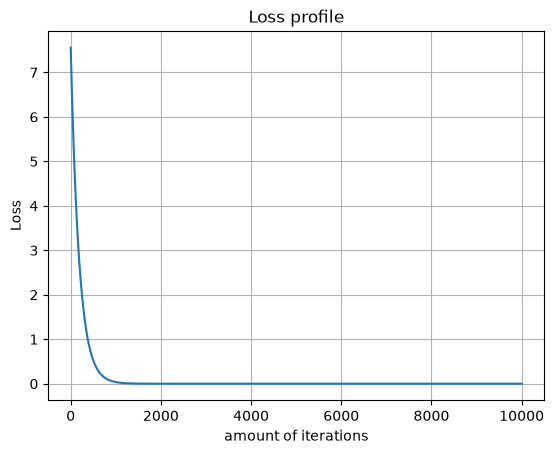

In [ ]:
import torch

torch.manual_seed(0)

# 1. Setup: Enable requires_grad
x = torch.ones(3)   # input tensor
y = torch.zeros(3)  # expected output
W = torch.randn(3, 3, requires_grad=True) # Track gradients
b = torch.randn(3, requires_grad=True)    # Track gradients

lr = 0.001
iterations = 10000

errors = np.zeros(iterations)

for epoch in range(iterations):
    # 2. Zero Gradients (Crucial Step)
    if W.grad is not None:
        W.grad.zero_()
    if b.grad is not None:
        b.grad.zero_()
    
    # 3. Forward Pass
    y_pred = torch.matmul(x, W)+b
    loss = ((y_pred - y) ** 2).mean()

    # Keep track of the loss
    errors[epoch] = loss.item()
    
    # 4. Backward Pass (Populates .grad)
    loss.backward()
    
    # 5. Manual Update (Disable tracking for the update step)
    with torch.no_grad():
        W -= lr * W.grad
        b -= lr * b.grad
        
        # Optional: Explicitly clear grads to free memory
        W.grad = None
        b.grad = None

    # Log at each ~1000 iterations
    if epoch % 1000 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item()}')

plt.plot(errors)
plt.title("Loss profile")
plt.xlabel("amount of iterations")
plt.ylabel("Loss")
plt.grid()


## Disabling Gradient Tracking

By default, all tensors with ``requires_grad=True`` are tracking their
computational history and support gradient computation. However, there
are some cases when we do not need to do that, for example, when we have
trained the model and just want to apply it to some input data, i.e. we
only want to do *forward* computations through the network. We can stop
tracking computations by surrounding our computation code with
``torch.no_grad()`` block:




In [ ]:
z = torch.matmul(x, w)+b
print(z.requires_grad)

with torch.no_grad():
    z = torch.matmul(x, w)+b
print(z.requires_grad)

Another way to achieve the same result is to use the ``detach()`` method
on the tensor:




In [ ]:
z = torch.matmul(x, w)+b
z_det = z.detach()
print(z_det.requires_grad)

There are reasons you might want to disable gradient tracking:
  - To mark some parameters in your neural network as **frozen parameters**.
  - To **speed up computations** when you are only doing forward pass, because computations on tensors that do
    not track gradients would be more efficient.



--- 

# Part 2: Model's Architecture

Models can express significantly complex predicting functions and we can not realistically model them in every small implementation details.

`Torch` provides a ready-to-use set of blocks that can be stacked together to sequentially build a chain of modules to express complex architectures.

Accordingly we may want first to review some basic blocks from `torch.nn`

## 2.2 Visualising model's Layers

As a first step we can directly try to initialise each individual building block as a separate object.

### 2.2.1 Basic Linear Layer

In [ ]:
# Dummy input tensor
x = torch.ones(2)

# Hidden and output layer
hidden_layer = torch.nn.Linear(in_features=2, out_features=4, bias=True)
output_layer = torch.nn.Linear(in_features=4, out_features=1, bias=True)

We can now explicitly visualise how are linear layers' parameters stored.

In [ ]:
print(
    "Hidden Layer:\n",
    hidden_layer.parameters().__next__(),
)

print(
    "\nOutput Layer:\n",
    output_layer.parameters().__next__(),
)

The `hidden_layer` and `output_layer` are now functions that take a Tensor in Input and return an output Tensor.


In [ ]:
# Compute the first hidden step and visualise the current shape
hidden = hidden_layer(x)
print("Hidden dimension:", hidden.shape)

# Compute the second (output) step and check dimension
output = output_layer(hidden)
print("Output dimension:", output.shape)

print("Model output:", output.item())

### 2.2.2 Convolutional Layer

Now that we now how to implement a simple layer let's move to the basic Convolutional ones.

We will use a `torch.nn.Conv2d` layer which accepts 2D information as input.

We need to adjust:
1. `in_channels` : Amount of channel in input.
2. `out_channels` : amount of channel as output.
3. `kernel_size` :  Dimension of the 2D filter.
4. `stride` : How to roll-out the kernel. 


In [ ]:
# Convolution parameters
in_channels  = 1
out_channels = 16
kernel_size  = (3, 3)
stride       = (2, 2)

# Convolutional Layer
conv1 = torch.nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=kernel_size, stride=stride)
 
print(
    "Conv Layer:\n",
    conv1.parameters().__next__(),
)

The amount of layer learnable parameters are as many kernel_size matrices as A random 2D tensor is generated and visualised.

Let's investigate the `kernel_size` and `stride` effect.

In [ ]:
import torch
import matplotlib.pyplot as plt

In [ ]:
import matplotlib.patches as patches

# Initialise a random tensor
H, W = 9, 9
x = torch.rand((H, W))

# Plot
_, ax = plt.subplots(1, 1, figsize=(7,7))

# Display random tensor
myplot = ax.imshow(x, vmin=0, vmax=1)

# Outer boundaries
for i in range(0, H, stride[0]):
    for j in range(0, W, stride[1]):
        square_out = patches.Rectangle(
            (i-0.5, j-0.5), kernel_size[0], kernel_size[1], 
            linewidth=2, edgecolor='orange', facecolor='none'
            )
        ax.add_patch(square_out)

# Inner boundaries
for i in range(0, H-kernel_size[0]+1, stride[0]):
    for j in range(0, W-kernel_size[1]+1, stride[1]): 
        square_in = patches.Rectangle(
            (
                (i-0.5) + (kernel_size[0] // 2), 
                (j-0.5) + (kernel_size[1] // 2),
            ),
            1, 1, linewidth=7, edgecolor='red', facecolor='none'
            )
        # Add the patch to the axes
        ax.add_patch(square_in)

plt.title("Input tensor")
plt.colorbar(myplot)
plt.show()

Convolutional layers need to operate on tensors made by 3 dimension which are:

(`channels`, `height`, `width`)

Our input tensor must therefore be have a channel dimension to be accepted and processed. We can set it to (1, H, W) and see if works or not.

Let's try to add an additional dimension on-the-fly with the: `torch.Tensor.unsqueeze()` method.

In [ ]:
print("Shape before unsqueezing:", x.shape)
x = x.unsqueeze(0)
print("Shape after unsqueezing: ", x.shape)

In [ ]:
conv_output = conv1(x)

print("Input shape: ", x.shape)
print("Output shape:", conv_output.shape)

And here is the visualisation of the layer outputs.

In [ ]:
_, axs = plt.subplots(1, out_channels, figsize=(out_channels*4,4))

# Estimate vmin, vmax
vmin, vmax = conv_output.min(), conv_output.max()
for channel_idx in range(out_channels):
    if out_channels == 1:
        ax = axs
    else:
        ax = axs[channel_idx]
    ax.set_title(
        f"Channel: {channel_idx+1}\nTesor Shape: {tuple(conv_output.shape[-2:])}"
        )
    myplot = ax.imshow(
            conv_output[channel_idx].detach().numpy(), vmin=vmin, vmax=vmax
        )
    plt.colorbar(myplot, ax = ax)
plt.suptitle("Output")
plt.show()

## 2.3 From Layers to Model

Modern Deep Learning approaches are made by architectures build on top of a significantly large and complex compositions of primitive learnable layers.
We need a more efficient approach to organise the internal model's layer in an easy-to-manage and re-usable manner to seamlessly train and deploy them later on.

We need to cast them in a `torch.nn.Module` class which is made by two essential internal methods (class functions):
1. `__init__`: Initialise the object and the internal learnable layers.
2. `forward`: takes the input tensor and generate the model output performing the forward pass by using the initialised layers as in __init__
. `

1.  `__init__`

Here's a simple example made by three consecutive convolutional layers which are assigned as class attributes.

```python
def __init__(
    self,
    in_channels: int,
    hidden_channels: int,
    out_channels: int,
    ) -> None:
    super().__init__() # Asking to inherit nn.Module properties 
    """
    Initialise the model learnable layers.
    """

    # Convolution options
    kernel_size = (3, 3)
    stride  = (1, 1)
    padding = (1, 1)

    # Learnable params
    self.input_conv_layer  = torch.nn.Conv2d(in_channels, hidden_channels, kernel_size, stride, padding)
    self.hidden_conv_layer = torch.nn.Conv2d(hidden_channels, hidden_channels, kernel_size, stride, padding)
    self.output_conv_layer = torch.nn.Conv2d(hidden_channels, out_channel, kernel_size, stride, padding)

```


 2. `forward`

 In which we basically collect the results at each stage of the intermediate hidden layers and return the model's output.

```python
def forward(self, x: torch.Tensor) -> torch.Tensor:
    """
    Perform the forward pass by using the learnable layers
    initialised as in __init__

    Args:
        x: (torch.Tensor), input tensor
    Return:
        output (torch.Tensor) f(x)
    """
    hidden_1 = self.input_conv_layer(x)
    hidden_2 = self.hidden_conv_layer(hidden_1)
    output   = self.output_conv_layer(hidden_2)

    return output

```

Let's wrap them into the actual model class.

In [ ]:
class MySimpleConvNet(torch.nn.Module):

    def __init__(
        self,
        in_channels: int,
        hidden_channels: int,
        out_channels: int,
        ) -> None:
        super().__init__()
        """
        Initialise the model learnable layers.
        """

        # Convolution options
        kernel_size = (3, 3)
        stride  = (1, 1)
        padding = (1, 1)

        # Learnable params
        self.input_conv_layer  = torch.nn.Conv2d(in_channels, hidden_channels, kernel_size, stride, padding, bias=False)
        self.hidden_conv_layer = torch.nn.Conv2d(hidden_channels, hidden_channels, kernel_size, stride, padding,  bias=False)
        self.output_conv_layer = torch.nn.Conv2d(hidden_channels, out_channels, kernel_size, stride, padding,  bias=False)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Perform the forward pass by using the learnable layers
        initialised as in __init__

        Args:
            x: (torch.Tensor), input tensor
        Return:
            output (torch.Tensor) f(x)
        """
        hidden_1 = self.input_conv_layer(x)
        hidden_2 = self.hidden_conv_layer(hidden_1)
        output   = self.output_conv_layer(hidden_2)
        return output

We can now estimate the amount of learnable parameters.

In [ ]:
from torchinfo import summary

# Instantiating the model
model = MySimpleConvNet(in_channels=1, hidden_channels=16, out_channels=1)

# Displaying params size and summary
print(summary(model))
for name, param in model.named_parameters():
    print(f"\nLayer: {name} | Size: {tuple(param.size())}")


## 2.4 Stacking multiple Models together



Here is an overview of an UNet ([Ronneberger et al. 2015](https://arxiv.org/abs/1505.04597)). The architecture is made by 3 components:

1. An "analysis" block (`DoubleConv`) 
2. An **Encoder** block: to compress the spatial dims and expand the channel one.
3. A **Decoder** block: to shrink the channel dim and enlarge the spatial ones.

Each of which is made by several layer and if we were to implement it from scratch, we would end up in a boilerplate code.
We can exploit sub-modules that can be iteratively initialised and recycled to build larger architectures.

![alt text](unet.png "Title")


In [ ]:
class DoubleConv(torch.nn.Module):
    def __init__(
            self,
            input_channels,
            output_channels,
            ) -> None:
        super().__init__()

        # Internal layers
        self.conv = torch.nn.Sequential(
            torch.nn.Conv2d(input_channels, output_channels, kernel_size=3, stride=1, padding=1, bias=False),
            torch.nn.BatchNorm2d(output_channels),
            torch.nn.ReLU(),
            torch.nn.Conv2d(output_channels, output_channels, kernel_size=3, stride=1, padding=1, bias=False),
            torch.nn.BatchNorm2d(output_channels),
            torch.nn.ReLU()
            )

    def forward(self, inputs):
        x = self.conv(inputs)
        return x


class EncoderBlock(torch.nn.Module):
    def __init__(
            self,
            input_channels,
            output_channels,
            ) -> None:
        super().__init__()

        # Internal layers
        self.conv = DoubleConv(input_channels, output_channels)
        self.pool = torch.nn.MaxPool2d(kernel_size=2, stride=2)
    
    def forward(self, inputs):
        x = self.conv(inputs)
        p = self.pool(x)
        return x, p


class DecoderBlock(torch.nn.Module):
    def __init__(
            self,
            input_channels,
            output_channels,
            ) -> None:
        super().__init__()

        # Internal layers
        self.up = torch.nn.ConvTranspose2d(input_channels, output_channels, kernel_size=2, stride=2, padding=0)
        self.conv = DoubleConv(output_channels*2, output_channels)
        
    def forward(self, inputs, skip):
        x = self.up(inputs)
        x = torch.cat([x, skip], axis=1)
        x = self.conv(x)
        return x

Let's build now the final class.

In [ ]:
class DownscalingUnet(torch.nn.Module):
    def __init__(
            self,
            input_channels: int,
            output_channels: int,
            features: list,
            **args,
            ) -> None:
        super().__init__()

        # Encoder
        self.encoder1 = EncoderBlock(input_channels, features[0], **args)
        self.encoder2 = EncoderBlock(features[0], features[1], **args)
        self.encoder3 = EncoderBlock(features[1], features[2], **args)
        self.encoder4 = EncoderBlock(features[2], features[3], **args) 

        # Bottleneck
        self.bottleneck = DoubleConv(features[3], features[3]*2, **args)  

        # Decoder
        self.decoder1 = DecoderBlock(features[3]*2, features[3], **args)
        self.decoder2 = DecoderBlock(features[3], features[2], **args)
        self.decoder3 = DecoderBlock(features[2], features[1], **args)
        self.decoder4 = DecoderBlock(features[1], features[0], **args)

        # output
        self.outputs = torch.nn.Conv2d(features[0], output_channels, kernel_size=1, padding=0)
    
    def forward(self, inputs):
        # Encoder
        # note: ss are for the skip connections!
        #       ps are results of an encoder block!
        s1, p1 = self.encoder1(inputs)
        s2, p2 = self.encoder2(p1)
        s3, p3 = self.encoder3(p2)
        s4, p4 = self.encoder4(p3)
        # Bottleneck
        b = self.bottleneck(p4)
        # Decoder
        d1 = self.decoder1(b,  s4)
        d2 = self.decoder2(d1, s3)
        d3 = self.decoder3(d2, s2)
        d4 = self.decoder4(d3, s1)
        # output
        outputs = self.outputs(d4)
        return outputs
    

In [ ]:
from torchinfo import summary

unet = DownscalingUnet(input_channels=1, output_channels=1, features=[64, 128, 256, 512])
    
print(summary(unet))
df = []
for name, param in unet.named_parameters():
    df.append(pd.DataFrame(
        {"layer": name, "size": f"{tuple(param.size())}"},
        index = [0]
        ))

pd.concat(df).head(30)

---

# Part 3: Datasets & DataLoaders

Code for processing data samples can get messy and hard to maintain.

We ideally want our dataset code to be decoupled from our model training code for better readability and modularity.

PyTorch provides two data primitives: 
1. **Dataset** : ``torch.utils.data.Dataset``
2. **DataLoader**  : ``torch.utils.data.DataLoader`` 

that allow you to use pre-loaded datasets as well as your own data.
``Dataset`` stores the samples and their corresponding labels, and ``DataLoader`` wraps an iterable around
the ``Dataset`` to enable easy access to the samples.


In [ ]:
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

## 3.1. Three fundamental Datasets methods


1. ``__init__``: it reads the two required structures: 
    1. the Sampler results (.csv) into a `pandas.DataFrame`.
    2. the Radar archive (.zarr) into a `xarray.Dataset`.

2. ``__len__``: Estimate the total lenght of possible iterable instances.

3. ``__getitem__``: return a sample from the dataset by a given index `idx`. In order this method:
    1. Reads the triplet of ($t, y, x$) coordinates associated to a given `idx` in the dataframe.
    2. Filter from the large datacube the temporal/spatial slice given ($t, y : y + \Delta y, x : x + \Delta x$) and load it as a tensor.
    3. Perform the coarsening of the high-resolution Radar data.
    4. Returns a pair of ($x_{LR}, x_{HR}$)



In [ ]:
import xarray as xr
from typing import Tuple

class DownscalingDataset(Dataset):

    def __init__(
            self,
            path_radar_dataset: str, 
            path_data_coordinates: str,
            downscaling_factor: int,
            delta_t: int, 
            delta_y: int,
            delta_x: int,
            return_normalised: bool,
            mode: str
        ) -> None:

        # Assign to dataset attributes
        self.path_radar_dataset = path_radar_dataset
        self.path_data_coordinates = path_data_coordinates
        self.downscaling_factor = downscaling_factor

        # Assign the information about deltas over dimensions
        self.delta_t = delta_t
        self.delta_y = delta_y
        self.delta_x = delta_x

        # Inform the data-fetching procedure to either normalise or not the radar data
        # Set to True for visualisation, False for training
        self.return_normalised = return_normalised

        # Modality: train, val or test
        assert mode in ("train", "val", "test"),\
            f"{mode} is not a valid splitting option!"+\
            "Accepted: ('train', 'val', 'test')"
        self.mode = mode

        # Read Radar Dataset in a xarray.Dataset
        self.radar_dataset = xr.open_dataset(
            self.path_radar_dataset,
            engine="zarr"
        )

        # Read importance sampler in a pandas.DataFrame
        self.data_coordinates = pd.read_parquet(
            self.path_data_coordinates
        )

        # Filter high precipitation events
        # self.data_coordinates = self.data_coordinates[self.data_coordinates["mean"]>2]
        self.data_coordinates = self.data_coordinates[
            (self.data_coordinates["frac_wet"] >= 0.25) & \
            (self.data_coordinates["mean"] >= 4.0)
            ]
        
        # Select the current modality and filter the data cordinates accordingly
        # Train set will cover the initial 80% of the whole sample amount
        # Val and Test will take 10 % each 
    
        if self.mode == "train":
            start_idx = 0
            end_idx   = int(len(self.data_coordinates)*0.8)
            
        elif self.mode == "val":
            start_idx = int(len(self.data_coordinates)*0.8)
            end_idx   = int(len(self.data_coordinates)*0.9)

        elif self.mode == "test":
            start_idx = int(len(self.data_coordinates)*0.9)
            end_idx   = int(len(self.data_coordinates)*1.0)
        
        # Extract the subset of coordinates sample which correspond to the (train, val, test) partition
        self.data_coordinates_subset = self.data_coordinates.iloc[start_idx : end_idx]


    def collect_data_coordinates(self, idx: int) -> Tuple[int, int, int]:
        """
        Read from the coordinate dataset and return the triplets of (t, y, x)
        """
        # Select the row associated to the idx
        current_row = self.data_coordinates_subset.iloc[idx]

        # Extract t, y, x
        t = int(current_row.t)
        y = int(current_row.y)
        x = int(current_row.x)

        return (t, y, x)


    def extract_dataslice_from_dataset(self, t: int, y: int, x: int) -> torch.Tensor:
        """
        Read the corresponding data-slice using t, y, x and the deltas.
        
        TODO: Return the sub-set by filtering the large datacube into a Tensor.
        """
        # Read from the whole datacube the information related to the current slice
        array = self.radar_dataset["RR"][t: t+self.delta_t,  y: y+self.delta_y,  x: x+self.delta_x].values

        # Convert it from numpy to torch.Tensor
        high_resolution = torch.from_numpy(array)

        return high_resolution
    

    def check_dataslice_dimension(self, data: torch.Tensor) -> torch.Tensor:
        """
        We might get into some boundaries conditions in which we are sampling
        Precipitation events outside the radar coverage.
        We need to make sure the read radar data matches the delta_x, delta_y
        dimention (256 x 256)
        
        Args:
            data: (torch.Tensor)
        TODO: Return data tensor of dim (..., delta_y, delta_x)
        """

        y, x = data.shape[-2:]
        if y < self.delta_y:
            diff = self.delta_y - y 
            data = torch.nn.functional.pad(data, (0, 0, diff//2, diff//2), mode="constant", value=0.0)
        if x < self.delta_x:
            diff = self.delta_x - x 
            data = torch.nn.functional.pad(data, (diff//2, diff//2, 0, 0), mode="constant", value=0.0)

        return data

    
    def fill_nan_values(self, data: torch.Tensor) -> torch.Tensor:
        """
        Convert nan values to 0 (mm/h)

        TODO: Return the input tensor replacing nans with 0s
        """
        zero_filled_data = torch.nan_to_num(data, nan=0.0)
        return zero_filled_data


    def generate_low_resolution(self, high_resolution: torch.Tensor) -> torch.Tensor: 
        """
        Convert high-resoluton data to low_resolution via interpolation.

        TODO: Return the interpolated high resolution.
        """
        # Interpolate the high_resolution by the down factor
        low_resolution = torch.nn.functional.interpolate(
            high_resolution.unsqueeze(0), # Need 4D tensor to apply the down factor
            scale_factor=1/self.downscaling_factor,
            mode="nearest",
            ).squeeze(0)

        # Interpolate back to match high_resolution dimension
        low_resolution = torch.nn.functional.interpolate(
            low_resolution.unsqueeze(0), # Need 4D tensor to apply the down factor
            scale_factor=self.downscaling_factor,
            mode="nearest",
            ).squeeze(0)
        
        return low_resolution


    def normalise_rainrate(self, data: torch.Tensor) -> torch.Tensor:
        """
        Convert rainrate values into (0, 1) range
        """
        # dBZ conversion
        eps, a, b = 1e-16, 200, 1.6
        data = data.to(torch.float32)  # Clamp does not work on float16
        dbz = 10.0 * torch.log10(a * torch.clamp(data, min=0) ** b + eps)
        dbz = torch.clamp(dbz, 0, 60)  # in a (0, 60) dBZ range

        # Range normalisation
        normalised_data = dbz / 60
        return normalised_data    


    def __len__(self):
        """
        (Mandatory) torch Dataset method

        TO DO: return the amount of items from the importance_sampler 
        """
        nrows, ncols = self.data_coordinates_subset.shape
        return nrows


    def __getitem__(self, idx: int):
        """
        (Mandatory) torch Dataset method.

        Yied a batch of (high-res, low-res) from a given idx.

        TODO: implement these steps.
            1. load the triplets of (t, y, x) from the sampler results.
            2. a) load the data-slice associated to (t, y, x).
               b) check for spatial dimension incosistency.
            3. Fill nan values with 0.
            4. Perform the coarsening of the high_resolution to generate the low_resolution.
            5. Normalise (high_res, low_res) in a (0,1) range
            6. Return a tuple of (high_res, low_res)
        """

        # 1 Get the triplets of coordinates from a given idx.
        t, y, x = self.collect_data_coordinates(idx)

        # 2.a Get the high-resolution radar image from the triplets of coordinates.
        high_resolution = self.extract_dataslice_from_dataset(t, y, x)

        # 2.b Check for data spatial dimension inconsitencies
        high_resolution = self.check_dataslice_dimension(high_resolution)

        # 3 Check for nans and fill them.
        high_resolution = self.fill_nan_values(high_resolution)

        # 4 Perform the coarsening of the high_resolution to generate the low_resolution.
        low_resolution = self.generate_low_resolution(high_resolution)

        # 5 Normalise (high_res, low_res) in a (0,1) range.
        if self.return_normalised:
            high_resolution = self.normalise_rainrate(high_resolution)
            low_resolution  = self.normalise_rainrate(low_resolution)

        # 6 Return a tuple of (high_res, low_res).
        return high_resolution, low_resolution


Let's initialise the dataset 

In [ ]:
downscaling_factor = 16
delta_t = 1
delta_y = 256
delta_x = 256

dataset = DownscalingDataset(
    path_radar_dataset="/disks/fast/italian-radar-dpc-sri-2010-2025.zarr",
    path_data_coordinates="/disks/fast/italian-radar-dpc-sri-2010-2025.parquet",
    downscaling_factor=downscaling_factor,
    delta_t=delta_t,
    delta_y=delta_y,
    delta_x=delta_x,
    return_normalised=False,
    mode="train"
)

print("Amount of filtered sample:", len(dataset))

In [ ]:
_, (axs) = plt.subplots(1, 3, figsize=(15, 5))


n    = dataset.data_coordinates.shape[0]
stats = {
    "frac_wet": {"title": "Fraction of wet pixels", "y": "Ratio", "x": "Idx"},
    "mean": {"title": "Avg rainrate", "y": "mm/h", "x": "Idx"},
    "nan_count": {"title": "Amount of NaNs", "y": "Ratio", "x": "Idx"},

}
for i, (stat_name, stat_attrs) in enumerate(stats.items()):
    
    data = dataset.data_coordinates[stat_name].values\
        if not stat_name == "nan_count" \
        else dataset.data_coordinates[stat_name].values / 256**2
    axs[i].plot(data, alpha=0.5)
    axs[i].vlines(int(n*0.8), color="red", ymin=data.min(), ymax=data.max())
    axs[i].vlines(int(n*0.9), color="red", ymin=data.min(), ymax=data.max())
    axs[i].vlines(n, color="red", ymin=data.min(), ymax=data.max())
    axs[i].set_title(stat_attrs["title"])
    axs[i].set_ylabel(stat_attrs["y"])
    axs[i].set_xlabel(stat_attrs["x"])


Display an example sample

In [ ]:
from pysteps.visualization import plot_precip_field

hr, lr = dataset[4000]

_, (ax_lr, ax_hr) = plt.subplots(1, 2, figsize=(12, 5))
plot_precip_field(lr.squeeze(), ax=ax_lr, colorscale="STEPS-BE")
plot_precip_field(hr.squeeze(), ax=ax_hr, colorscale="STEPS-BE")
ax_lr.set_title(f"Interpolated Low-Resolution")
ax_hr.set_title(f"High-resolution")
plt.suptitle(f"Example from Downscaling Dataset\n(Downscaling factor: x{downscaling_factor})")
plt.show()

## 3.2 Dataloaders

While training a model, we typically want to
pass samples in "minibatches", reshuffle the data at every epoch to reduce model overfitting, and use Python's ``multiprocessing`` to
speed up data retrieval.

``DataLoader`` is an iterable that abstracts this complexity for us in an easy API.


In [ ]:
from torch.utils.data import DataLoader

# Init a dataset
training_data = DownscalingDataset(
    path_radar_dataset="/disks/fast/italian-radar-dpc-sri-2010-2025.zarr",
    path_data_coordinates="/disks/fast/italian-radar-dpc-sri-2010-2025.parquet",
    downscaling_factor=downscaling_factor,
    delta_t=delta_t,
    delta_y=delta_y,
    delta_x=delta_x,
    return_normalised=True,
    mode="train"
)

val_data = DownscalingDataset(
    path_radar_dataset="/disks/fast/italian-radar-dpc-sri-2010-2025.zarr",
    path_data_coordinates="/disks/fast/italian-radar-dpc-sri-2010-2025.parquet",
    downscaling_factor=downscaling_factor,
    delta_t=delta_t,
    delta_y=delta_y,
    delta_x=delta_x,
    return_normalised=True,
    mode="val"
)

# Cast it in the dataloader
train_dataloader = DataLoader(training_data, num_workers=4, batch_size=8, shuffle=True)
val_dataloader   = DataLoader(val_data, num_workers=4, batch_size=8, shuffle=False)


---

# Part 4: The Training Loop


## Get Device for Training
We want to be able to train our model on a hardware accelerator like the GPU or 
if available. Let's check to see if [torch.cuda](https://pytorch.org/docs/stable/notes/cuda.html)
is available, otherwise we use the CPU.



In [ ]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using '{device}' device")

## Optimizing Model Parameters

Now that we have a model and data it's time to train, validate and test our model by optimizing its parameters on
our data. Training a model is an iterative process; in each iteration the model makes a guess about the output, calculates
the error in its guess (*loss*), collects the derivatives of the error with respect to its parameters (as we saw in
the Autorgrad section above, and **optimizes** these parameters using gradient descent. For a more
detailed walkthrough of this process, check out this video on [backpropagation from 3Blue1Brown](https://www.youtube.com/watch?v=tIeHLnjs5U8).


## Hyperparameters

Hyperparameters are adjustable parameters that let you control the model optimization process.
Different hyperparameter values can impact model training and convergence rates
([read more](https://pytorch.org/tutorials/beginner/hyperparameter_tuning_tutorial.html)_ about hyperparameter tuning)

We define the following hyperparameters for training:
 - **Number of Epochs** - the number times to iterate over the dataset
 - **Batch Size** - the number of data samples propagated through the network before the parameters are updated
 - **Learning Rate** - how much to update models parameters at each batch/epoch. Smaller values yield slow learning speed, while large values may result in unpredictable behavior during training.




In [ ]:
epochs        = 10
learning_rate = 1e-3
batch_size    = 8

## Optimization Loop

Once we set our hyperparameters, we can then train and optimize our model with an optimization loop. Each
iteration of the optimization loop is called an **epoch**.

Each epoch consists of two main parts:
 - **The Train Loop** - iterate over the training dataset and try to converge to optimal parameters.
 - **The Validation Loop** - iterate over the test dataset to check if model performance is improving.

Let's briefly familiarize ourselves with some of the concepts used in the training loop. Jump ahead to
see the `full-impl-label` of the optimization loop.

### Loss Function

When presented with some training data, our untrained network is likely not to give the correct
answer. **Loss function** measures the degree of dissimilarity of obtained result to the target value,
and it is the loss function that we want to minimize during training. To calculate the loss we make a
prediction using the inputs of our given data sample and compare it against the true data label value.

We pass our model's output logits to ``nn.MSELoss``, which will normalize the logits and compute the prediction error.



In [ ]:
# Initialize the loss function
loss_fn = torch.nn.MSELoss()

### Optimizer

Optimization is the process of adjusting model parameters to reduce model error in each training step. **Optimization algorithms** define how this process is performed (in this example we use Stochastic Gradient Descent).
All optimization logic is encapsulated in  the ``optimizer`` object. Here, we use the SGD optimizer; additionally, there are many [different optimizers](https://pytorch.org/docs/stable/optim.html)
available in PyTorch such as ADAM and RMSProp, that work better for different kinds of models and data.

We initialize the optimizer by registering the model's parameters that need to be trained, and passing in the learning rate hyperparameter.



In [ ]:
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

Inside the training loop, optimization happens in three steps:
 * Call ``optimizer.zero_grad()`` to reset the gradients of model parameters. Gradients by default add up; to prevent double-counting, we explicitly zero them at each iteration.
 * Backpropagate the prediction loss with a call to ``loss.backward()``. PyTorch deposits the gradients of the loss w.r.t. each parameter.
 * Once we have our gradients, we call ``optimizer.step()`` to adjust the parameters by the gradients collected in the backward pass.



---
# Full Implementation
We define the following helper functions to split the training process in sub-blocks:
1. ``train_model`` perform the full model training over n epochs.
2. ``train_loop`` that loops over our optimization code and updates model parameters for a single epoch.
3. ``val_loop`` that temporarily freeze model's params to perform the validation on the validation set for a single epoch.
4. ````denormalise_to_rainrate```` converts the resulting tensors from model's output from (0, 1) to mm/h.
5. ``visualize`` to have a perceptive overview of the resulting reconstructed high-resolution fields while training.
6. ``plot_loss`` to show the loss reduction trends.



In [ ]:
def train_model(
        model: torch.nn.Module,
        optimizer: torch.optim.Optimizer,
        loss_fn: torch.nn.Module,
        train_dataloader: torch.utils.data.DataLoader,
        val_dataloader: torch.utils.data.DataLoader,
        epochs: int,
        output_path: str,
    ) -> None:
    """
    Perform full model training.
    """
    # Keep track of avg loss  and per epoch and per batch
    avg_train_loss_array = np.array([])
    avg_val_loss_array = np.array([])
    train_loss_array = np.array([])
    val_loss_array = np.array([])

    # Keep track of the best val performance
    best_val_loss = np.inf

    # Loop over epochs
    for t in range(epochs):

        print(f"\n{'-'*40}\nEpoch: {t+1}\n{'-'*40}")

        # Perform Train Loop
        curr_avg_train_loss, curr_train_loss_array = \
            train_loop(train_dataloader, model, loss_fn, optimizer)
        
        # Perform Val Loop
        curr_avg_val_loss, curr_val_loss_array = \
            val_loop(val_dataloader, model, loss_fn)

        # Concatenate the loss values performed at each batch
        avg_train_loss_array = np.concat([avg_train_loss_array, np.array((curr_avg_train_loss,))])
        avg_val_loss_array = np.concat([avg_val_loss_array, np.array((curr_avg_val_loss,))])
        train_loss_array = np.concat([train_loss_array, curr_train_loss_array])
        val_loss_array = np.concat([val_loss_array, curr_val_loss_array])

        # Check for the best performance
        if curr_avg_val_loss < best_val_loss:

            # Mark the current as the new best val
            best_val_loss = curr_avg_val_loss

            # Save model
            print("Best model! saving ckpt...")
            torch.save(model, os.path.join(output_path, "best.ckpt"))

        # Visualise intermediate results
        idxs = [4,  436, ]
        visualize(val_dataloader, model, idxs)
            
    print("Done!")
    return (
        avg_train_loss_array,
        avg_val_loss_array,
        train_loss_array,
        val_loss_array,
    )

def train_loop(dataloader, model, loss_fn, optimizer):
    """
    Perform a single epoch, looping over the dataloader.
    """
    # Set the model to training mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.train()
    
    # Initialise a counter for the loss value
    train_loss = 0
    n_sample   = 0
    loss_array = np.zeros(len(dataloader))

    # Loop over batches
    progress_bar = tqdm(dataloader, total=len(dataloader))
    for batch_idx, (high_res, low_res) in enumerate(progress_bar):

        # Collect current batch_size
        batch_size = high_res.shape[0]

        # Moving tensor to device
        high_res = high_res.to(device)
        low_res = low_res.to(device)

        # Compute predicted high-resolution precipitation from low-resolution
        pred = model(low_res)

        # Compute the loss by comparing the real high-resolution with the prediction
        loss = loss_fn(pred, high_res)

        # Backpropagation: compute gradients, update model's params
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        # Collect current loss value performed on the batch
        current_loss = loss.item()

        # Keep track of loss value
        train_loss += current_loss
        
        # Keep track of the amount of sample
        n_sample += batch_size

        # Save loss values
        loss_array[batch_idx] = train_loss / n_sample

        # Update progressbar description
        pbar_description = f"Batch idx: ({batch_idx}) " \
            + f"Loss: ({(train_loss / n_sample):>7f}) " \
            + f"Batch size: ({batch_size})"
        progress_bar.set_postfix_str(pbar_description)

    # Return the avg train loss
    avg_train_loss = train_loss / n_sample
    print(f"Avg train loss: {avg_train_loss:>7f}")
    return avg_train_loss, loss_array


def val_loop(dataloader, model, loss_fn):
    """
    Perform a single loop over the validation dataloader.
    """
    model.eval()

    # Initialise a counter for the loss value
    val_loss = 0
    n_sample = 0
    loss_array = np.zeros(len(dataloader))

    # Evaluating the model with torch.no_grad() ensures that no gradients are computed during test mode
    # also serves to reduce unnecessary gradient computations and memory usage for tensors with requires_grad=True
    with torch.no_grad():

        # Loop over batches
        progress_bar = tqdm(dataloader, total=len(dataloader))
        for batch_idx, (high_res, low_res) in enumerate(progress_bar):

            # Estimate batch_size 
            batch_size = high_res.shape[0]

            # Moving tensor to device
            high_res = high_res.to(device)
            low_res = low_res.to(device)
        
            # Compute the forward pass
            pred = model(low_res)

            # Estimate the loss 
            loss = loss_fn(pred, high_res)

            # Collect the val loss 
            current_loss = loss.item()

            # Update the val_loss counter
            val_loss += current_loss

            # Keep track of the amount of sample
            n_sample += batch_size

            # Save loss values
            loss_array[batch_idx] = val_loss / n_sample

            # Update progressbar description
            pbar_description = f"Batch idx: ({batch_idx}) " \
                + f"Loss: ({(val_loss / n_sample):>7f}) " \
                + f"Batch size: ({batch_size})"
            progress_bar.set_postfix_str(pbar_description)

    # Return the avg val loss
    avg_val_loss = val_loss / n_sample
    print(f"Avg loss: {avg_val_loss:>8f}")
    return avg_val_loss, loss_array


def denormalise_to_rainrate(data: np.ndarray) -> np.ndarray:
    """
    Convert the normalised tensor from normalised range (0, 1) back to mm/h.
    """
    a, b = 200, 1.6
    # From (0,1) to dbz
    data_dbz = data * 60
    z_lin = (10.0 ** (data_dbz / 10.0)).clip(min=1e-6)
    rr = (z_lin / a) ** (1.0 / b)
    return np.where(rr < 0.04, np.zeros_like(rr), rr)


def visualize(dataloader, model, idxs):
    """
    Provide a quick visualisation while training the model
    """
    with torch.no_grad():
            
        for idx in idxs:
            high_res, low_res = dataloader.dataset[idx]
            low_res = low_res.unsqueeze(0).to(device)

            # Perfom model output:
            downscaled = model(low_res)

            _, axs = plt.subplots(1, 3, figsize=(12, 4))
            for i, (data, title) in enumerate([
                (low_res, "Low-resolution"),
                (downscaled, "Downscaled Low-res"),
                (high_res, "High-Resolution Radar"),
                ]):

                data = data.to("cpu").numpy().squeeze()
                data = denormalise_to_rainrate(data)
                plot_precip_field(data, ax=axs[i], colorscale="STEPS-BE")
                axs[i].set_title(title)
            plt.show()

def plot_loss(train_loss: np.ndarray, val_loss: np.ndarray, mvavg: int=10):
    """
    Plot Train and Val Performance with moving window avg.
    """
    _, (train_ax, val_ax) = plt.subplots(1, 2, figsize=(12, 4))

    train_ax.plot(train_loss, alpha=0.8, label="loss")
    train_ax.plot(pd.Series(train_loss).rolling(window=mvavg).mean().values, color="red", linewidth=3, label="smoothed")
    train_ax.grid(alpha=0.4)
    train_ax.set_title("Train Loss")
    train_ax.set_ylim(0.0, 0.0025)

    val_ax.plot(val_loss, alpha=0.8, label="loss")
    val_ax.plot(pd.Series(val_loss).rolling(window=mvavg).mean().values, color="red", linewidth=3, label="smoothed")
    val_ax.set_title("Val Loss")
    val_ax.grid(alpha=0.4)
    plt.legend()

We are now ready to train and inspect the downscaling experiment.

In [ ]:
from torchsummary import summary 

# Init training hyperparameters
epochs        = 15
learning_rate = 0.001
batch_size    = 32

# Init model/optimisation objects
train_dataloader = DataLoader(training_data, num_workers=8, batch_size=batch_size, shuffle=True)
val_dataloader   = DataLoader(val_data, num_workers=8, batch_size=batch_size, shuffle=False)
model            = DownscalingUnet(input_channels=1, output_channels=1, features=[8, 16, 32, 64]).to(device)
optimizer        = torch.optim.Adam(model.parameters(), lr=learning_rate)
loss_fn          = torch.nn.MSELoss()
output_path = "./"

# Visualise model summary
print(summary(model, (1, 256, 256)))

# Run training
avg_train_loss_array, avg_val_loss_array, train_loss_array, val_loss_array = \
    train_model(
        model,
        optimizer,
        loss_fn,
        train_dataloader,
        val_dataloader,
        epochs,
        output_path,
    )

In [ ]:
plot_loss(train_loss_array, val_loss_array)
plot_loss(avg_train_loss_array, avg_val_loss_array, mvavg=1)

Testing the training model on some test example

In [ ]:
test_data = DownscalingDataset(
    path_radar_dataset="/disks/fast/italian-radar-dpc-sri-2010-2025.zarr",
    path_data_coordinates="/disks/fast/italian-radar-dpc-sri-2020-2025.parquet",
    downscaling_factor=downscaling_factor,
    delta_t=delta_t,
    delta_y=delta_y,
    delta_x=delta_x,
    return_normalised=True,
    mode="test"
)

dataloader = DataLoader(val_data, num_workers=1, batch_size=1, shuffle=False)

# Load best model
model = torch.load(os.path.join(output_path, "best.ckpt"), weights_only=False)

with torch.no_grad():
    
    progress_bar = tqdm(dataloader, total=len(dataloader))
    for batch_idx, (high_res, low_res) in enumerate(progress_bar):

        # Avoid doing inference on poor precipitation events
        if denormalise_to_rainrate(high_res.numpy()).sum() < 1e5:
            continue
        
        # Loading the low_res to the device
        low_res = low_res.to(device)

        # Perfom model output:
        downscaled = model(low_res)

        _, axs = plt.subplots(1, 3, figsize=(12, 4))
        for i, (data, title) in enumerate([
            (low_res, "Low-resolution"),
            (downscaled, "Downscaled Low-res"),
            (high_res, "High-Resolution Radar"),
            ]):

            data = data.to("cpu").numpy().squeeze()
            data = denormalise_to_rainrate(data)
            plot_precip_field(data, ax=axs[i], colorscale="STEPS-BE")
            axs[i].set_title(title)
        plt.show()

        